<a href="https://colab.research.google.com/github/PedroHNeves1505/CP2-SERS-Semestre-2/blob/main/CP2_SERS_Semestre_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Checkpoint 2 | SERS | 2°Semestre**


#**==== EXERCÍCIO ====**<br>
Treinar modelo de classificação usando o algoritmo de regressão logística (no sklearn --> Logistic Regresion) para prever se a rede elétrica está INSTÁVEL OU ESTÁVEL. Metricas para avaliação: acurácia, precisão e a matriz de confusão

Qual será o atributo alvo y (target) --> coluna 'stabf' com duas classes 'stable' e 'unstable'

Quais serão as nossas features (x)? --> todas os atributos, exceto 'stab' e 'stabf'

###**==== PREPARAÇÃO DO AMBIENTE ====**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

###**==== PROJETO ====**

In [3]:
# Carregando arquivo .csv do github para Jupyter Notebook
# Passo a Passo --> github -> arquivo .csv ->  botão Raw -> copia link da pág -> importa com pandas
dados = pd.read_csv('https://raw.githubusercontent.com/PedroHNeves1505/CP2-SERS-Semestre-2/refs/heads/main/Raw_Data.csv')

In [4]:
# OBJETIVOS DO PROJETO

# 1. Faça uma inspeção de dados
# 2. Quais classes existem na coluna alvo 'stabf'?
# 3. Quantos registros tem em cada classe?
# 4. Separar features (x) e target (y)
# 5. Separar dados de treino e teste
# 6. Instanciar objeto 'modelo' a partir da classe LogisticRegression
# 7. Treinar, gerar provisões e avaliar
# 8. Gerar matriz de confusão, usando heatmap e seaborn

1. Faça uma inspeção de dados

In [5]:
# Faça uma inspeção de dados
# Apresenta as primeiras x linhas do dataset
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [6]:
# Faça uma inspeção de dados
# Apresenta tipo da coluna
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [7]:
# Faça uma inspeção de dados
# Apresenta um resumo estatístico dos numericos do dataset
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [8]:
# Faça uma inspeção de dados
# Apresenta um resumo estatístico dos objetos do dataset
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [9]:
# 2. Quais classes existem na coluna alvo 'stabf'?
# Apresenta quantidade de linhas e colunas do dataset
linhas, colunas = dados.shape
print(f'Linhas: {linhas}\nColunas: {colunas}')

Linhas: 10000
Colunas: 14


2. Quais classes existem na coluna alvo 'stabf'?

In [10]:
# 2. Quais classes existem na coluna alvo 'stabf'?
# Mostra quais são os valores presentes na coluna x
cont = 1
for classe in dados['stabf'].unique():
  print(f'{cont}. {classe}')
  cont += 1

1. unstable
2. stable


In [11]:
# 2. Quais classes existem na coluna alvo 'stabf'?
# Renomeia as valores da coluna x
dados['stabf'] = dados['stabf'].replace({'unstable': 'REDE INSTÀVEL', 'stable': 'REDE ESTÁVEL'})

In [12]:
# 2. Quais classes existem na coluna alvo 'stabf'?
# Mostra quais são os valores presentes na coluna x
cont = 1
for classe in dados['stabf'].unique():
  print(f'{cont}. {classe}')
  cont += 1

1. REDE INSTÀVEL
2. REDE ESTÁVEL


3. Quantos registros tem em cada classe?

In [13]:
# 3. Quantos registros tem em cada classe?
# Apresenta quantidade de aparições de cada valor em uma coluna
dados['stabf'].value_counts()

,count
stabf,
REDE INSTÀVEL,6380
REDE ESTÁVEL,3620


4. Separar features (x) e target (y)

In [14]:
# 4. Separar features (x) e target (y)
# Remove as colunas
x = dados.drop(['stab', 'stabf'], axis=1)
y = dados['stabf']

5. Separar dados de treino e teste

In [15]:
# 5. Separar dados de treino e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

6. Instanciar objeto 'modelo' a partir da classe LogisticRegression

In [16]:
# 6. Instanciar objeto 'modelo' a partir da classe LogisticRegression
modelo = LogisticRegression()

7. Treinar, gerar provisões e avaliar

In [17]:
# 7. Treinar, gerar provisões e avaliar
# Escrever resumo dps
modelo.fit(x_train, y_train)
provisoes = modelo.predict(x_test)


In [18]:
# 7. Treinar, gerar provisões e avaliar
# Escrever resumo dps
y_prob = modelo.predict_proba(x_test)
y_prob[:50]

array([[0.04609348, 0.95390652],
       [0.06082634, 0.93917366],
       [0.31665189, 0.68334811],
       [0.97845447, 0.02154553],
       [0.64488737, 0.35511263],
       [0.57310264, 0.42689736],
       [0.7293308 , 0.2706692 ],
       [0.0220369 , 0.9779631 ],
       [0.04455238, 0.95544762],
       [0.74263825, 0.25736175],
       [0.05821672, 0.94178328],
       [0.43539611, 0.56460389],
       [0.54821046, 0.45178954],
       [0.22628137, 0.77371863],
       [0.01738045, 0.98261955],
       [0.24059749, 0.75940251],
       [0.43383254, 0.56616746],
       [0.19235057, 0.80764943],
       [0.42956875, 0.57043125],
       [0.30915071, 0.69084929],
       [0.08327983, 0.91672017],
       [0.1285647 , 0.8714353 ],
       [0.19005429, 0.80994571],
       [0.77021981, 0.22978019],
       [0.34514059, 0.65485941],
       [0.29155465, 0.70844535],
       [0.61401301, 0.38598699],
       [0.48196263, 0.51803737],
       [0.69575885, 0.30424115],
       [0.92903344, 0.07096656],
       [0.

In [19]:
# 7. Treinar, gerar provisões e avaliar
# fazer reumo dps
y_pred = modelo.predict(x_test)
y_pred[:50]

array(['REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE ESTÁVEL',
       'REDE ESTÁVEL', 'REDE ESTÁVEL', 'REDE ESTÁVEL', 'REDE INSTÀVEL',
       'REDE INSTÀVEL', 'REDE ESTÁVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL',
       'REDE ESTÁVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL',
       'REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL',
       'REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE ESTÁVEL',
       'REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE ESTÁVEL', 'REDE INSTÀVEL',
       'REDE ESTÁVEL', 'REDE ESTÁVEL', 'REDE INSTÀVEL', 'REDE ESTÁVEL',
       'REDE ESTÁVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL',
       'REDE ESTÁVEL', 'REDE ESTÁVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL',
       'REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE INSTÀVEL', 'REDE ESTÁVEL',
       'REDE ESTÁVEL', 'REDE INSTÀVEL', 'REDE ESTÁVEL', 'REDE INSTÀVEL',
       'REDE ESTÁVEL', 'REDE ESTÁVEL'], dtype=object)

In [20]:
# 7. Treinar, gerar provisões e avaliar
# Fazer resumo dps
acurracy = 100 * accuracy_score(y_test, y_pred)
print(f'Acurracy: {acurracy:.2f}%')

Acurracy: 81.70%


Text(70.72222222222221, 0.5, 'Valores Reais')

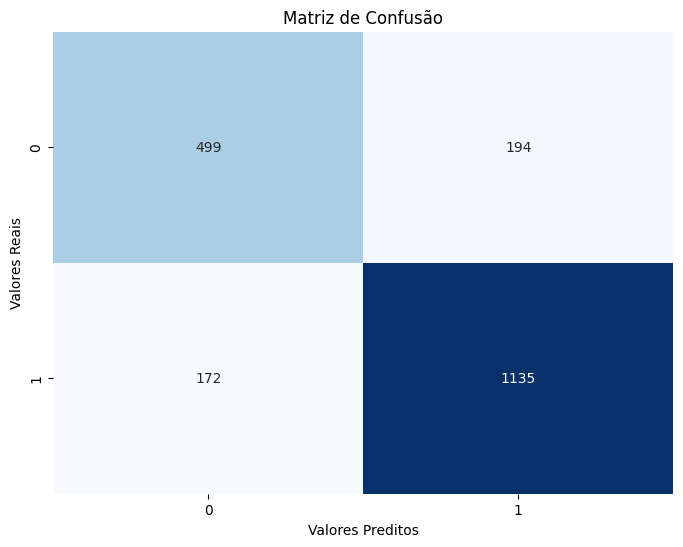

In [22]:
# 8. Gerar matriz de confusão, usando heatmap e seaborn
# Faz uma matriz de confusão com gráficos
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão')
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')